# Grafica Pendiente vs Elevacion



Codigo para graficar el cambio de la pendiente de acuerdo con la elevacion, considerando la frecuencia de las celdas. Graficas utilizadas por *Wegmann, S. F. G., Franke, K. L., Hughes, S., Lewis, R. Q., Lyons, N., Paris, P., Ross, K., Bauer, J. B., & Witt, A. C. (2011). Hillslope response to knickpoint migration in the Southern Appalachians: Implications for the evolution of post-orogenic landscapes. Earth Surface Processes and Landforms, 36(9), 1254–1267. https://doi.org/10.1002/esp.2150*

In [1]:
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import DataFrame
import geopandas as gpd

import warnings
warnings.filterwarnings("ignore")

### San Mateo

,OBJECTID,Id,gridcode,Área,Nombre,ID_CUENCA,hypso_inte,area_curva,Knickpoint,geometry
0,360,351.0,128.0,224.388925,Quebrada San Mateo,351,0.428,0.413412,B,"MULTIPOLYGON (((401245.641 682383.875, 401258...."


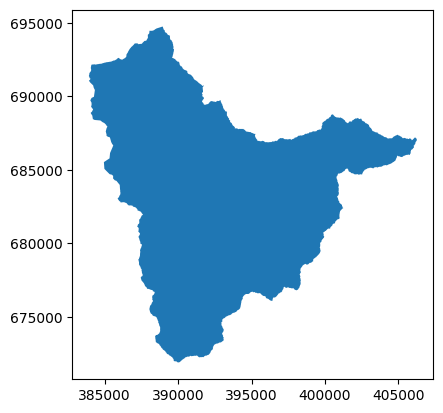

In [2]:
cuenca=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/cauca/Vector/sanmateo_30m.gpkg')
cuenca.plot()
cuenca.head(2)

(1436138,)

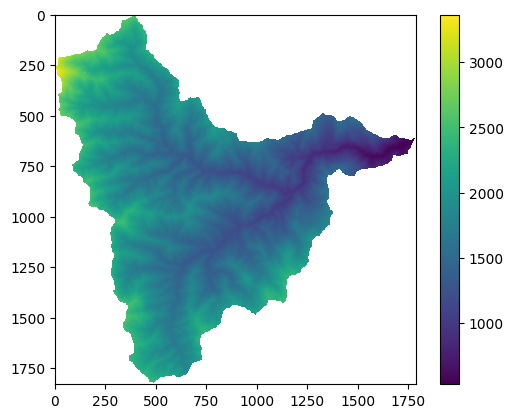

In [3]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/cauca/Raster/sanmateo_DEM_12m.tif')
alt=raster.read(1)
alt=np.where(alt<0,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
alt_vector_MenM=alt_vector[~np.isnan(alt_vector)] # para eliminar  del vector los datos NaN
plt.imshow(alt)
plt.colorbar();
alt_vector_MenM.shape # otra forma de saber las dimensiones

(1438685,)

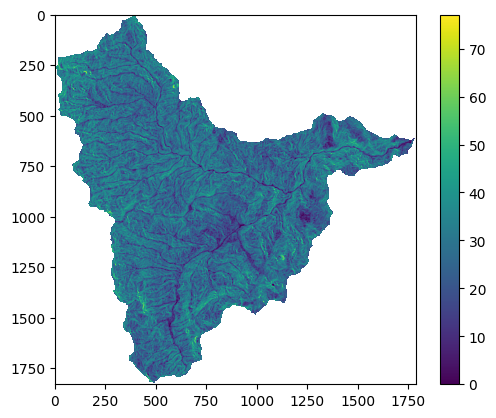

In [4]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/cauca/Raster/sanmateo_slope_12m.tif')
pendiente=raster.read(1)
pendiente=np.where(pendiente<0,np.nan,pendiente)
pendiente_vector=pendiente.ravel()
pendiente_vector_MenM=pendiente_vector[~np.isnan(pendiente_vector)]
plt.imshow(pendiente)
plt.colorbar();
pendiente_vector_MenM.shape

In [5]:
# Se prefiere trabajar con el vector que incluye los NaN ya que tiene las mismas filas
pend_serie=pd.Series(pendiente_vector,name="pend")
alt_serie=pd.Series(alt_vector,name="alt")
df=pd.merge(alt_serie,pend_serie, right_index=True, left_index=True)
df.head()

,alt,pend
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


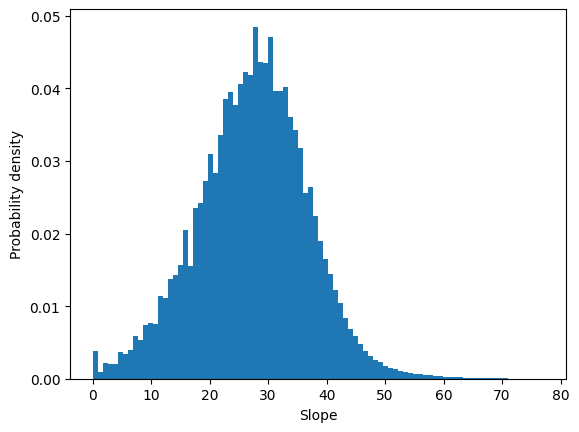

In [6]:
f, ax = plt.subplots()
ax.hist(df["pend"],bins=90, density=True)
ax.set_xlabel('Slope')
ax.set_ylabel('Probability density');

### MenM recientes

,Name,Fecha,SAMPLE_1,geometry
0,Jan2018,01/2018,2268.0,POINT Z (-75.47982 6.32703 0.00000)
1,May2008,05/2008,2328.0,POINT Z (-75.64809 6.24041 0.00000)


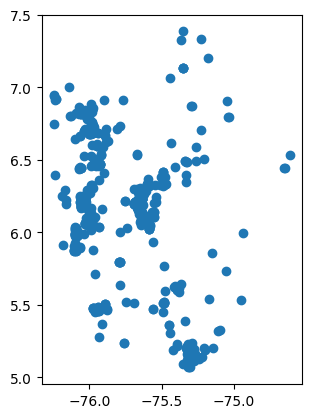

In [9]:
elevation=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent_elevation.gpkg')
elevation.plot()
elevation.head(2)

In [10]:
rec_ele=elevation.drop(["Name",'Fecha'],axis=1)
rec_ele=rec_ele.to_crs(epsg=32618)
rec_ele.rename(columns={"SAMPLE_1":"elevation"}, inplace=True)
rec_ele.head(2)

,elevation,geometry
0,2268.0,POINT Z (446930.432 699380.028 0.000)
1,2328.0,POINT Z (428307.201 689824.340 0.000)


,Fecha,slope1,geometry
0,01/2018,32.057217,POINT Z (-75.47982 6.32703 0.00000)
1,05/2008,22.874903,POINT Z (-75.64809 6.24041 0.00000)


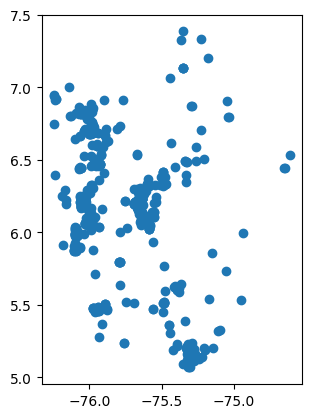

In [11]:
slope=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent_slope_12m.gpkg')
slope.plot()
slope.head(2)

In [12]:
rec_slop=slope.drop(['Fecha'],axis=1)
rec_slop=rec_slop.to_crs(epsg=32618)
rec_slop.rename(columns={"slope1":"slope"}, inplace=True)
rec_slop.head(2)

,slope,geometry
0,32.057217,POINT Z (446930.432 699380.028 0.000)
1,22.874903,POINT Z (428307.201 689824.340 0.000)


In [13]:
rec=pd.merge(rec_slop,rec_ele, right_index=True, left_index=True)
rec=rec.set_geometry(rec.geometry_y)
rec.drop(['geometry_x','geometry_y'],axis=1,inplace=True)
rec.head()

,slope,elevation,geometry
0,32.057217,2268.0,POINT Z (446930.432 699380.028 0.000)
1,22.874903,2328.0,POINT Z (428307.201 689824.340 0.000)
2,11.143301,1939.0,POINT Z (426011.245 685946.287 0.000)
3,30.963758,1988.0,POINT Z (425957.361 685813.081 0.000)
4,27.123791,1951.0,POINT Z (425936.618 685609.788 0.000)


<Axes: >

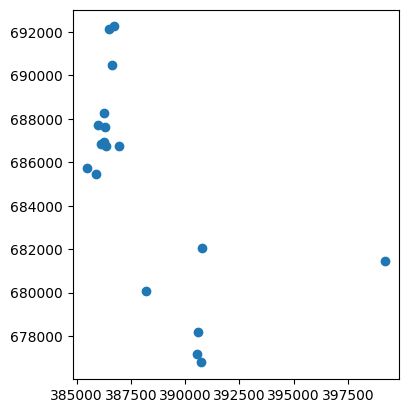

In [14]:
rec_cuenca = gpd.sjoin(rec, cuenca, how="inner", op='intersects')
rec_cuenca.plot()

### MenM Relictos

,Name,elevation1,geometry
0,El Guasimo,777.0,POINT Z (-75.86709 6.80850 753.10776)
1,El Noral,1613.0,POINT Z (-75.50832 6.36266 1592.60560)


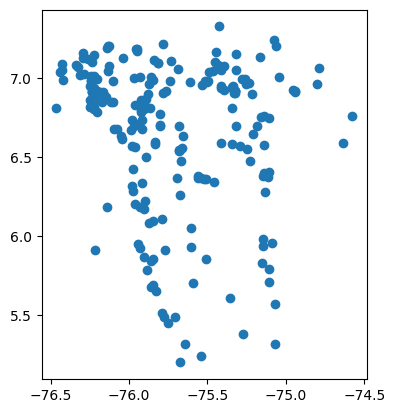

In [15]:
elevation=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_elevation.gpkg')
elevation.plot()
elevation.head(2)

In [16]:
rel_ele=elevation.drop(["Name"],axis=1)
rel_ele=rel_ele.to_crs(epsg=32618)
rel_ele.rename(columns={"elevation1":"elevation"}, inplace=True)
rel_ele.head(2)

,elevation,geometry
0,777.0,POINT Z (404187.110 752665.590 753.108)
1,1613.0,POINT Z (443782.345 703321.444 1592.606)


,Name,slope1,geometry
0,El Guasimo,15.119460,POINT Z (-75.86709 6.80850 753.10776)
1,El Noral,13.873369,POINT Z (-75.50832 6.36266 1592.60560)


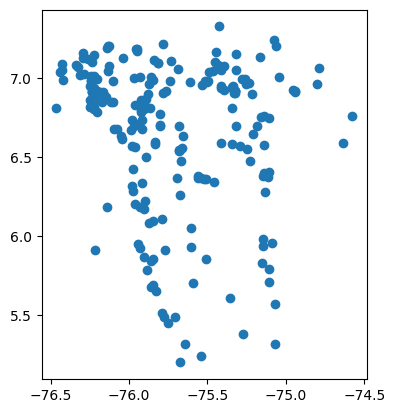

In [17]:
slope=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_slope_12m.gpkg')
slope.plot()
slope.head(2)

In [18]:
rel_slop=slope.drop(['Name'],axis=1)
rel_slop=rel_slop.to_crs(epsg=32618)
rel_slop.rename(columns={"slope1":"slope"}, inplace=True)
rel_slop.head(2)

,slope,geometry
0,15.119460,POINT Z (404187.110 752665.590 753.108)
1,13.873369,POINT Z (443782.345 703321.444 1592.606)


In [19]:
rel=pd.merge(rel_slop,rel_ele, right_index=True, left_index=True)
rel=rel.set_geometry(rel.geometry_y)
rel.drop(['geometry_x','geometry_y'],axis=1,inplace=True)
rel.head()

,slope,elevation,geometry
0,15.119460,777.0,POINT Z (404187.110 752665.590 753.108)
1,13.873369,1613.0,POINT Z (443782.345 703321.444 1592.606)
2,30.486488,1526.0,POINT Z (411214.965 741208.592 1506.569)
3,35.858368,2051.0,POINT Z (397878.994 758139.395 2042.377)
4,38.328819,1536.0,POINT Z (400192.726 757568.355 1528.623)


<Axes: >

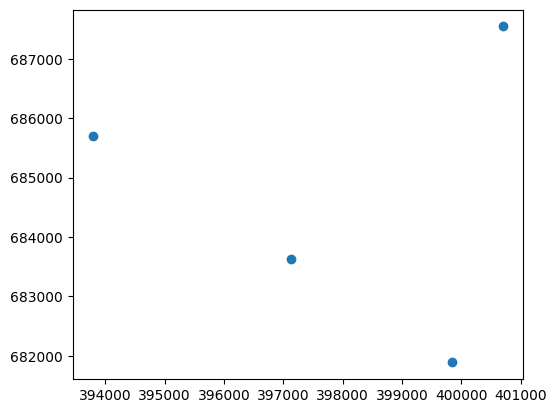

In [20]:
rel_cuenca = gpd.sjoin(rel, cuenca, how="inner", op='intersects')
rel_cuenca.plot()

In [21]:
from math import ceil
dx=(alt_serie.max()-alt_serie.min())/99
sorted_df = df.sort_values(by=['alt'], ascending=True)
alt ={}
pend={}
total=0
for x,y in zip(sorted_df["alt"], sorted_df["pend"]):
    if (pd.isna(x))or(pd.isna(y)):
        continue
    total+=1
    k = ceil(x+1)//dx
    alt.setdefault(k, []).append(x)
    pend.setdefault(k, []).append(y)
b = list(alt.values())
c = list(pend.values())

# calculate the mean, max, min, frequency
alt_mean=[]
alt_freq=[]
hypso=[]
for x in range(len(b)):
  alt_mean.append(np.mean(b[x]))
  alt_freq.append(len(b[x]))
  hypso.append(len(b[x])/total)

# calculate the mean, max, min, frequency
pend_mean=[]
pend_std=[]
pend_min=[]
pend_max=[]
pend_freq=[]
for x in range(len(c)):
  pend_mean.append(np.mean(c[x]))
  pend_std.append(np.std(c[x]))
  pend_min.append(min(c[x]))
  pend_max.append(max(c[x]))
  pend_freq.append(len(c[x]))

#calcular la desviacion estandar de la pendiente
std1=[a_i - b_i for a_i, b_i in zip(pend_mean, pend_std)]
std2=[a_i + b_i for a_i, b_i in zip(pend_mean, pend_std)]

# calcular el acumulado de cuva hipsometrica
hypso_cum=1-np.cumsum(hypso)

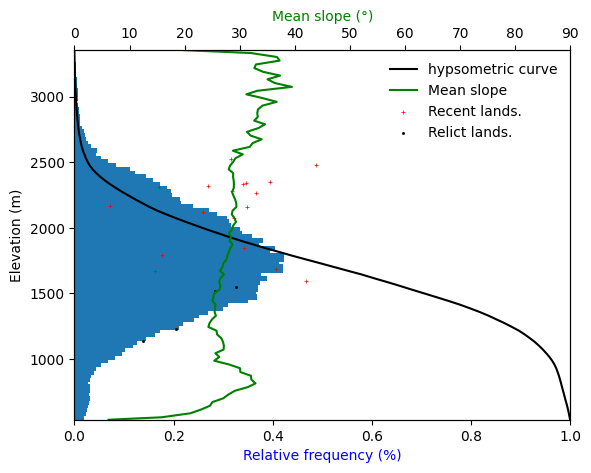

In [22]:
f, ax = plt.subplots()

ax1=ax.twiny()
ax1.plot(pend_mean,alt_mean,'g-',label="Mean slope")
#ax1.plot(std1,alt_mean,'k--',linewidth=0.5,alpha=0.5,label="Std")
#ax1.plot(std2,alt_mean,'k--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_min,alt_mean,'g--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_max,alt_mean,'g--',linewidth=0.5,alpha=0.4,label="Max. slope")
ax1.scatter(rec_cuenca.slope,rec_cuenca.elevation,color='r',marker='+',s=10,linewidths=0.5,label='Recent lands.')
ax1.scatter(rel_cuenca.slope,rel_cuenca.elevation,color='k',marker='.',s=10,linewidths=0.5,label='Relict lands.')
ax1.set_xlim(0,90)
ax1.set_xlabel("Mean slope (°)",color='green')
ax1.set_ylim(top=max(alt_mean),bottom=min(alt_mean))

frequency=[15*x/(total) for x in alt_freq] # se multiplica por 0.1 el denominador para que se vea mas la frecuencia en la grafica (multiplicar x10)
ax.barh(alt_mean,frequency, height=40)
ax.set_ylabel('Elevation (m)')
ax.set_xlabel("Relative frequency (%)",color='blue')
ax.set_xlim(0,10)
ax.plot(hypso_cum,alt_mean,'k-',label="hypsometric curve")
ax.set_xlim(0,1)
ax.set_ylim(top=max(alt_mean),bottom=min(alt_mean))

#axin=ax.inset_axes([0.52,0.5,0.52,0.5])
#cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/cuencas_areaestudio.shp")
#aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
#aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
#rec.plot(ax=axin,marker='.',color='red',markersize=1)
#rel.plot(ax=axin,marker='+',color='black',markersize=1)
#focus = cat.loc[[46], ['geometry']]
#focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
#focus = cat.loc[[18], ['geometry']]
#focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
#axin.set_axis_off()

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, ncol=1, loc="upper right",prop={'size': 10},frameon=False)

plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/sanmateo_elev_slope.png");

### Tonusco

,OBJECTID,Id,gridcode,Área,Nombre,ID_CUENCA,hypso_inte,area_curva,Knickpoint,geometry
0,351,342.0,118.0,415.240245,Río Tonusco,342,0.47,0.45528,B,"MULTIPOLYGON (((408695.641 719221.375, 408708...."


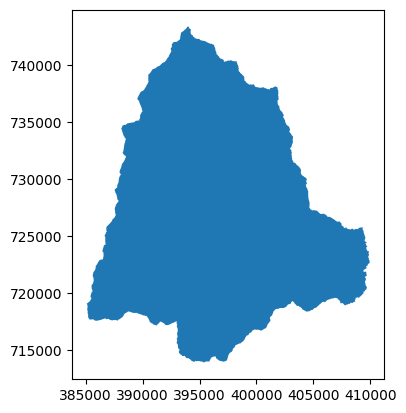

In [23]:
cuenca=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/cauca/Vector/tonusco_30m.gpkg')
cuenca.plot()
cuenca.head(2)

(2657535,)

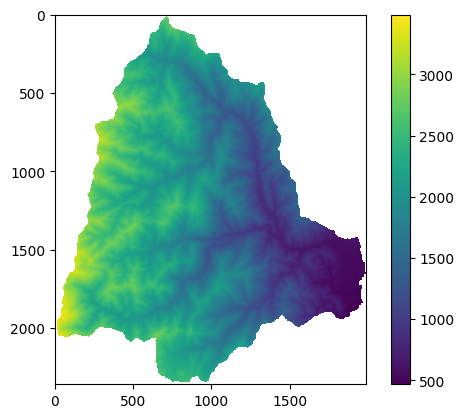

In [7]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/cauca/Raster/tonusco_12m.tif')
alt=raster.read(1)
alt=np.where(alt<0,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
alt_vector_MenM=alt_vector[~np.isnan(alt_vector)] # para eliminar  del vector los datos NaN
plt.imshow(alt)
plt.colorbar();
alt_vector_MenM.shape # otra forma de saber las dimensiones

(2660406,)

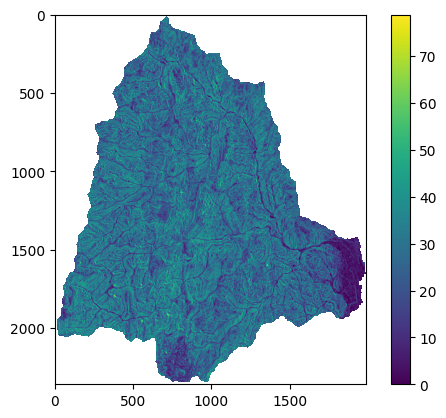

In [8]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Cauca/Raster/tonusco_slope_12m.tif')
pendiente=raster.read(1)
pendiente=np.where(pendiente<0,np.nan,pendiente)
pendiente_vector=pendiente.ravel()
pendiente_vector_MenM=pendiente_vector[~np.isnan(pendiente_vector)]
plt.imshow(pendiente)
plt.colorbar();
pendiente_vector_MenM.shape

In [9]:
pend_serie=pd.Series(pendiente_vector,name="pend")
alt_serie=pd.Series(alt_vector,name="alt")
df=pd.merge(alt_serie,pend_serie, right_index=True, left_index=True)
df.head()

,alt,pend
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


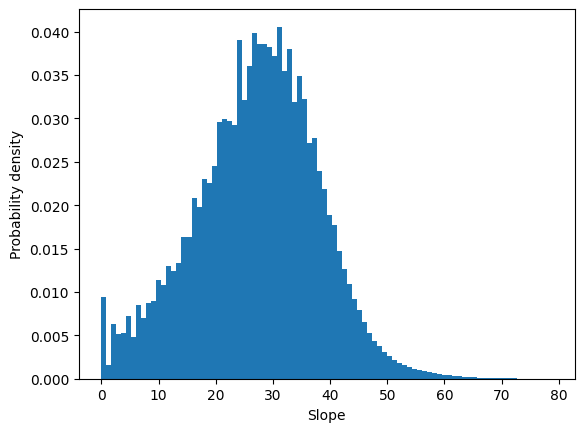

In [10]:
f, ax = plt.subplots()
ax.hist(df["pend"],bins=90, density=True)
ax.set_xlabel('Slope')
ax.set_ylabel('Probability density');

<Axes: >

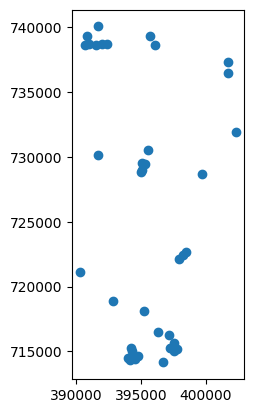

In [29]:
rec_cuenca = gpd.sjoin(rec, cuenca, how="inner", op='intersects')
rec_cuenca.plot()

<Axes: >

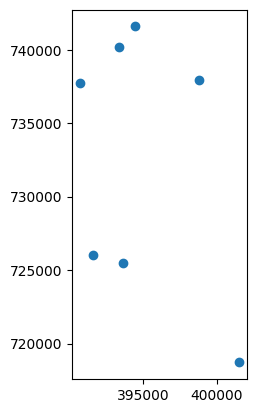

In [30]:
rel_cuenca = gpd.sjoin(rel, cuenca, how="inner", op='intersects')
rel_cuenca.plot()

In [31]:
from math import ceil
dx=(alt_serie.max()-alt_serie.min())/99
sorted_df = df.sort_values(by=['alt'], ascending=True)
alt ={}
pend={}
total=0
for x,y in zip(sorted_df["alt"], sorted_df["pend"]):
    if (pd.isna(x))or(pd.isna(y)):
        continue
    total+=1
    k = ceil(x+1)//dx
    alt.setdefault(k, []).append(x)
    pend.setdefault(k, []).append(y)
b = list(alt.values())
c = list(pend.values())

# calculate the mean, max, min, frequency
alt_mean=[]
alt_freq=[]
hypso=[]
for x in range(len(b)):
  alt_mean.append(np.mean(b[x]))
  alt_freq.append(len(b[x]))
  hypso.append(len(b[x])/total)

# calculate the mean, max, min, frequency
pend_mean=[]
pend_std=[]
pend_min=[]
pend_max=[]
pend_freq=[]
for x in range(len(c)):
  pend_mean.append(np.mean(c[x]))
  pend_std.append(np.std(c[x]))
  pend_min.append(min(c[x]))
  pend_max.append(max(c[x]))
  pend_freq.append(len(c[x]))

#calcular la desviacion estandar de la pendiente
std1=[a_i - b_i for a_i, b_i in zip(pend_mean, pend_std)]
std2=[a_i + b_i for a_i, b_i in zip(pend_mean, pend_std)]

# calcular el acumulado de cuva hipsometrica
hypso_cum=1-np.cumsum(hypso)

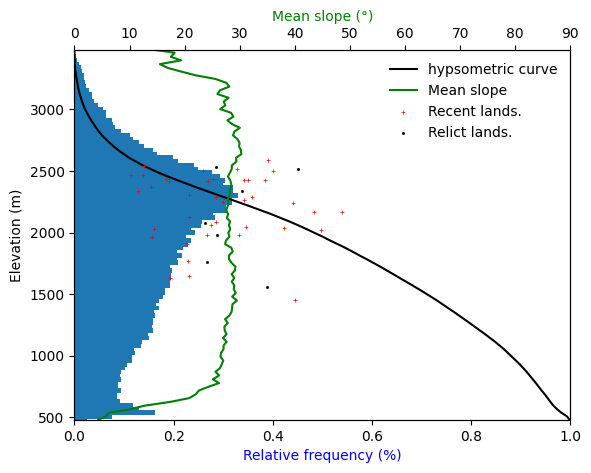

In [32]:
f, ax = plt.subplots()

ax1=ax.twiny()
ax1.plot(pend_mean,alt_mean,'g-',label="Mean slope")
#ax1.plot(std1,alt_mean,'k--',linewidth=0.5,alpha=0.5,label="Std")
#ax1.plot(std2,alt_mean,'k--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_min,alt_mean,'g--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_max,alt_mean,'g--',linewidth=0.5,alpha=0.4,label="Max. slope")
ax1.scatter(rec_cuenca.slope,rec_cuenca.elevation,color='r',marker='+',s=10,linewidths=0.5,label='Recent lands.')
ax1.scatter(rel_cuenca.slope,rel_cuenca.elevation,color='k',marker='.',s=10,linewidths=0.5,label='Relict lands.')
ax1.set_xlim(0,90)
ax1.set_xlabel("Mean slope (°)",color='green')
ax1.set_ylim(top=max(alt_mean),bottom=min(alt_mean))

frequency=[15*x/(total) for x in alt_freq] # se multiplica por 0.1 el denominador para que se vea mas la frecuencia en la grafica (multiplicar x10)
ax.barh(alt_mean,frequency, height=40)
ax.set_ylabel('Elevation (m)')
ax.set_xlabel("Relative frequency (%)",color='blue')
ax.set_xlim(0,10)
ax.plot(hypso_cum,alt_mean,'k-',label="hypsometric curve")
ax.set_xlim(0,1)
ax.set_ylim(top=max(alt_mean),bottom=min(alt_mean))

#axin=ax.inset_axes([0.52,0.5,0.52,0.5])
#cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/cuencas_areaestudio.shp")
#aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
#aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
#rec.plot(ax=axin,marker='.',color='red',markersize=1)
#rel.plot(ax=axin,marker='+',color='black',markersize=1)
#focus = cat.loc[[46], ['geometry']]
#focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
#focus = cat.loc[[18], ['geometry']]
#focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
#axin.set_axis_off()

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, ncol=1, loc="upper right",prop={'size': 10},frameon=False)

plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/tonusco_elev_slope.png");